In [1]:
satellite_addresses = {
    'swot_nadir': 'SWOT_L2_NALT_GDR_SSHA_2.0',
    'jason_2': '',
    'jason_3': 'JASON_3_L2_OST_OGDR_GPS'
}

In [4]:
!pip install copernicusmarine

   ---------------------------------------- 0.0/15.4 MB ? eta -:--:--
   ------ --------------------------------- 2.4/15.4 MB 12.2 MB/s eta 0:00:02
   ----------- ---------------------------- 4.5/15.4 MB 10.7 MB/s eta 0:00:02
   --------------- ------------------------ 6.0/15.4 MB 9.7 MB/s eta 0:00:01
   ------------------- -------------------- 7.6/15.4 MB 9.2 MB/s eta 0:00:01
   ----------------------- ---------------- 9.2/15.4 MB 8.8 MB/s eta 0:00:01
   --------------------------- ------------ 10.7/15.4 MB 8.5 MB/s eta 0:00:01
   -------------------------------- ------- 12.3/15.4 MB 8.3 MB/s eta 0:00:01
   ------------------------------------ --- 13.9/15.4 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------  15.2/15.4 MB 8.2 MB/s eta 0:00:01
   ---------------------------------------- 15.4/15.4 MB 7.9 MB/s  0:00:01
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 13.3 MB/s  0:00:00
   ----------

In [ ]:
from pathlib import Path

import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import copernicusmarine

import cartopy.crs as ccrs
import cartopy.feature as cfeature


c:\Users\pesen\Documents\UCL Masters Coursework\Masters Project SWOT\swot_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [124]:
from display_tracks import display_1D_tracks

In [3]:
?copernicusmarine.subset

Signature:
copernicusmarine.subset(
    dataset_id: str | None = None,
    dataset_version: str | None = None,
    dataset_part: str | None = None,
    username: str | None = None,
    password: str | None = None,
    variables: list[str] | None = None,
    minimum_longitude: float | None = None,
    maximum_longitude: float | None = None,
    minimum_latitude: float | None = None,
    maximum_latitude: float | None = None,
    minimum_depth: float | None = None,
    maximum_depth: float | None = None,
    vertical_axis: Literal['depth', 'elevation'] = 'depth',
    start_datetime: datetime.datetime | pandas.Timestamp | str | None = None,
    end_datetime: datetime.datetime | pandas.Timestamp | str | None = None,
    minimum_x: float | None = None,
    maximum_x: float | None = None,
    minimum_y: float | None = None,
    maximum_y: float | None = None,
    coordinates_selection_method: Literal['inside', 'strict-inside', 'nearest', 'outside'] = 'inside',
    output_filename: str | None

In [6]:
copernicusmarine.subset(
   dataset_id = "cmems_obs-sl_glo_phy-ssh_nrt_swon-l3-duacs_PT1S",
   variables = ["sla_filtered"],
   start_datetime = "2024-01-01",
   end_datetime = "2024-01-02",
   output_directory = Path('./data') / 'swot_nadir_l3',
   file_format = 'netcdf'
)

INFO - 2026-07-16T18:50:14Z - Selected dataset version: "202311"
INFO - 2026-07-16T18:50:14Z - Selected dataset part: "default"
100%|██████████| [00:01<00:00]
INFO - 2026-07-16T18:50:22Z - Produced 1 NetCDF file(s) in data\swot_nadir_l3\cmems_obs-sl_glo_phy-ssh_nrt_swon-l3-duacs_PT1S_sla_filtered_2024-01-01-2024-01-02


ResponseSubset(file_path=WindowsPath('data/swot_nadir_l3/cmems_obs-sl_glo_phy-ssh_nrt_swon-l3-duacs_PT1S_sla_filtered_2024-01-01-2024-01-02'), output_directory=WindowsPath('data/swot_nadir_l3'), filename='cmems_obs-sl_glo_phy-ssh_nrt_swon-l3-duacs_PT1S_sla_filtered_2024-01-01-2024-01-02', file_size=None, data_transfer_size=None, variables=['sla_filtered'], coordinates_extent=[], status='000', message='The request was successful.', file_status='DOWNLOADED', file_names=['SWOT_nadir_28days.nc'])

In [4]:
ds = xr.open_dataset('./data/swot_nadir_l3/cmems_obs-sl_glo_phy-ssh_nrt_swon-l3-duacs_PT1S_sla_filtered_2024-01-01-2024-01-02/SWOT_nadir_28days.nc')
display(ds)
ssha = ds['sla_filtered'].assign_coords(
    time=ds['time'], 
    latitude=ds['latitude'], 
    longitude=ds['longitude']
)
display(ssha)

<xarray.Dataset> Size: 1MB
Dimensions:       (time: 44115)
Coordinates:
  * time          (time) datetime64[ns] 353kB 2024-01-01 ... 2024-01-02
    longitude     (time) float64 353kB ...
    latitude      (time) float64 353kB ...
Data variables:
    sla_filtered  (time) float64 353kB ...
Attributes: (12/23)
    institution:                       CLS, CNES
    doi:                               https://doi.org/10.48670/moi-00147
    time_coverage_start:               2024-01-01T00:00:00Z
    time_coverage_end:                 2024-01-02T00:00:00Z
    last_date_observation:             2024-01-02T00:00:00Z
    geospatial_lat_min:                -77.63847
    ...                                ...
    product_id:                        SEALEVEL_GLO_PHY_L3_NRT_008_044
    dataset_id:                        cmems_obs-sl_glo_phy-ssh_nrt_swon-l3-d...
    Conventions:                       CF-1.9 ACDD-1.3
    title:                             Subset of dataset cmems_obs-sl_glo_phy...
    contact:                           servicedesk.cmems@mercator-ocean.eu
    history:                           2026-07-16T19:50:22.387950: Subset fro...

<xarray.DataArray 'sla_filtered' (time: 44115)> Size: 353kB
[44115 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 353kB 2024-01-01 ... 2024-01-02
    longitude  (time) float64 353kB ...
    latitude   (time) float64 353kB ...
Attributes:
    standard_name:  sea_surface_height_above_sea_level
    units:          m

In [42]:
def open_half_orbit(karin_or_nadir, file_name, display_xarray=False):
    
    if karin_or_nadir not in ['karin', 'nadir']:
        raise ValueError(f"Invalid argument: '{karin_or_nadir}'. Must be 'karin' or 'nadir'.")

    file_path = Path('./data') / karin_or_nadir / file_name

    if not file_path.exists():
        raise FileNotFoundError(f"Dataset not found at expected path: {file_path}")

    if karin_or_nadir == 'karin':
        ds = xr.open_dataset(file_path)
        if display_xarray:
            display(ds)

        ssha = (ds['ssha_karin_2'] + ds['height_cor_xover']).assign_coords(
            time=ds['time'],
            latitude=ds['latitude'],
            longitude=ds['longitude']
        )
    
    elif karin_or_nadir == 'nadir':
        ds = xr.open_dataset(file_path, group='data_01')
        if display_xarray:
            display(ds)

        ds_ku = xr.open_dataset(file_path, group='data_01/ku')
        if display_xarray:
            display(ds_ku)

        ssha = ds_ku['ssha'].assign_coords(
            time=ds['time'], 
            latitude=ds['latitude'], 
            longitude=ds['longitude']
        )

    return ssha

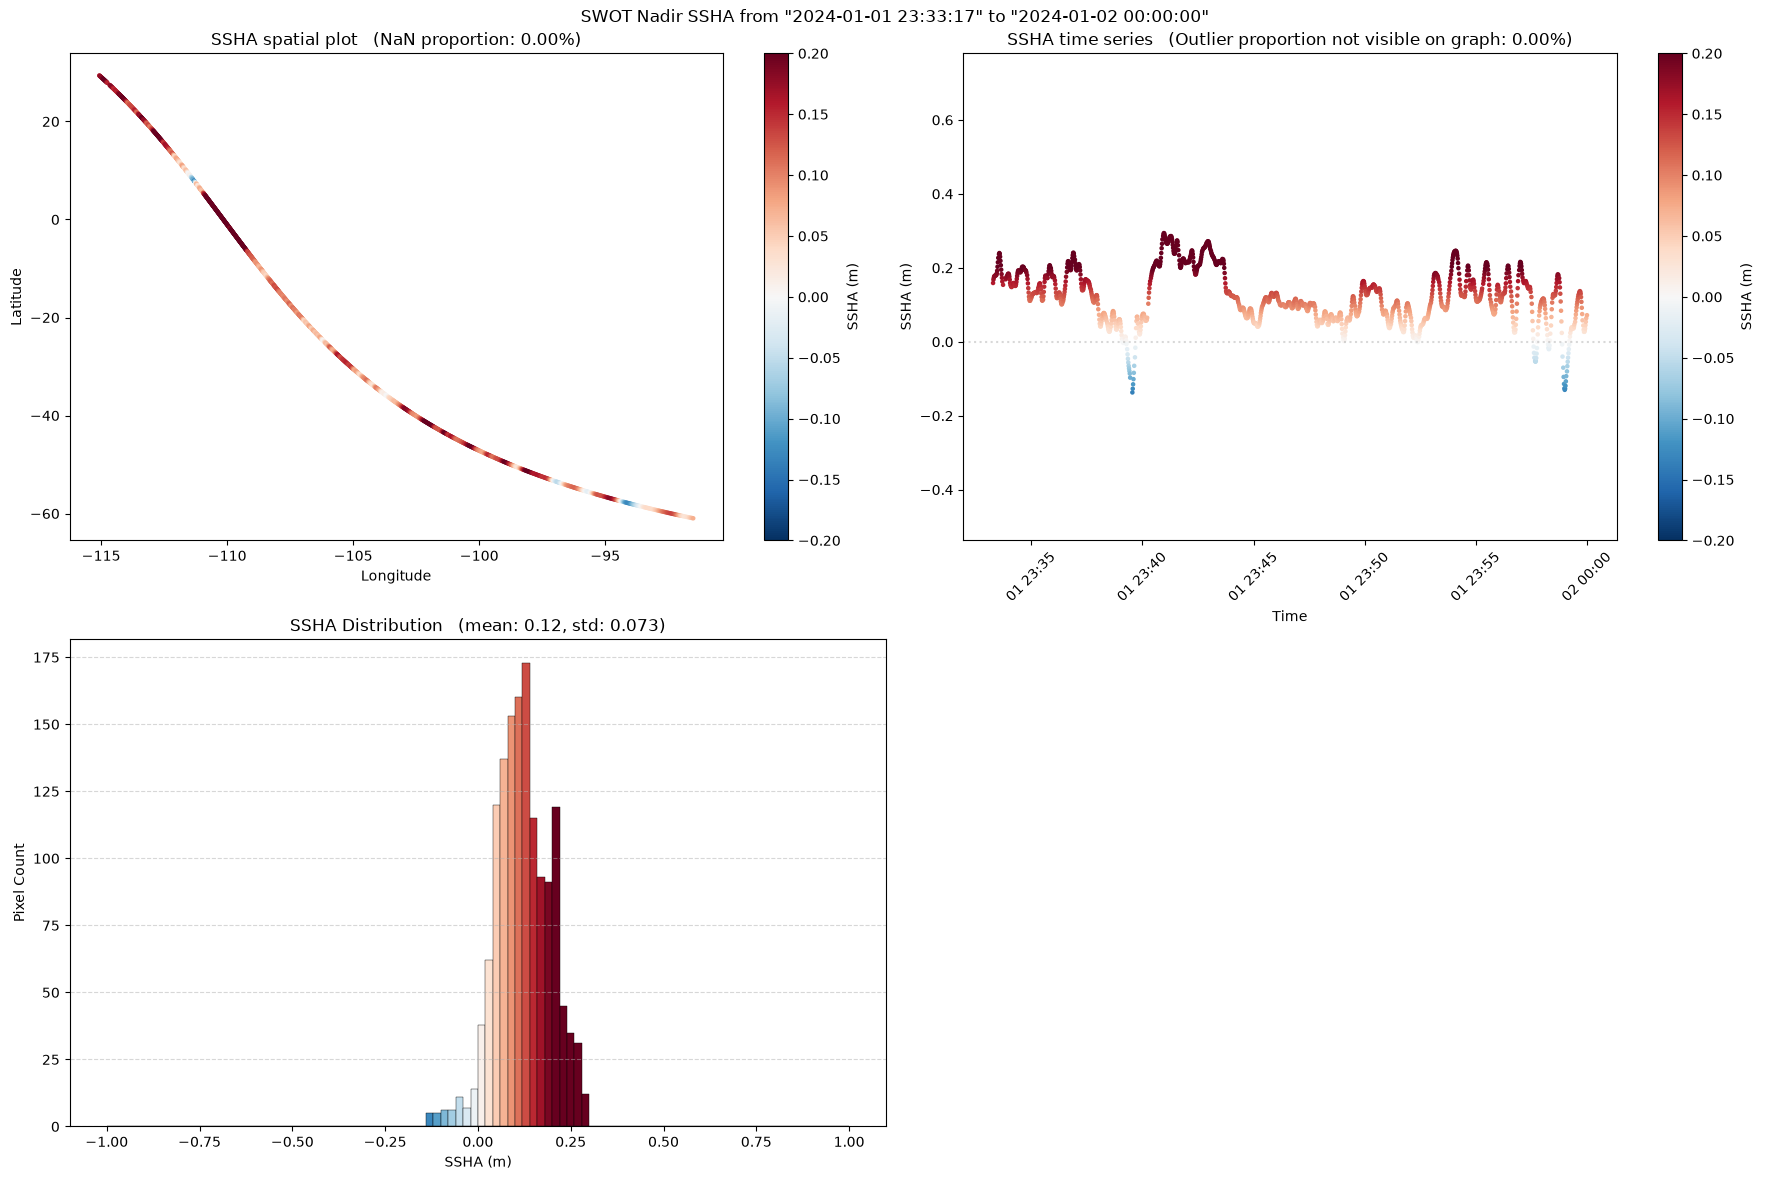

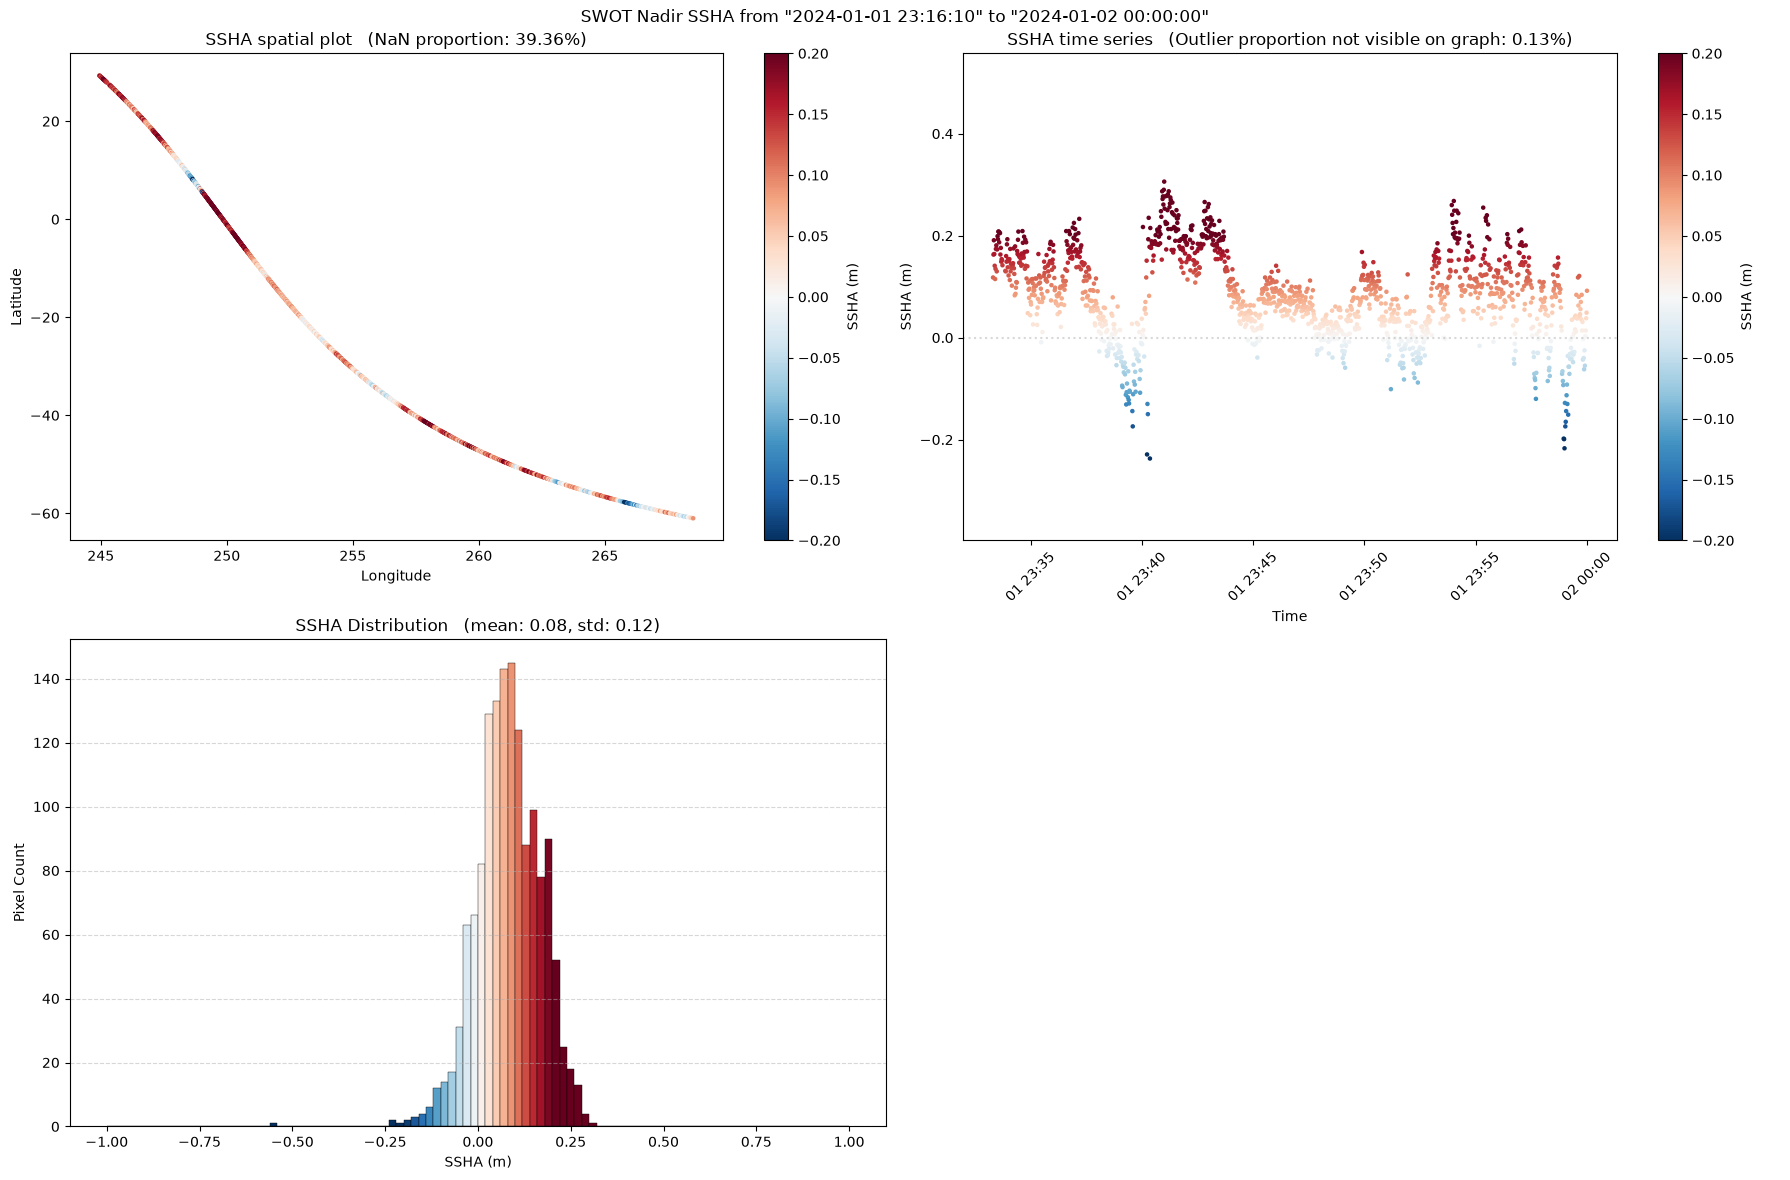

In [125]:
start_time = '2024-01-01T23:16:00'
end_time = '2024-01-02T00:00:00'

display_1D_tracks(ssha.sel(time=slice(start_time, end_time)), outlier_threshold=9)

ssha_nadir = open_half_orbit('nadir', 'SWOT_GPR_2PfP008_524_20240101_231610_20240102_000737.nc')

display_1D_tracks(ssha_nadir.sel(time=slice(start_time, end_time)))
        